In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

from sklearn.metrics import class_likelihood_ratios, recall_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)



In [26]:
bootstrap_columns = [f"target_bootstrap_{n}" for n in range(1000)]

# 30-day Mortality

In [27]:
combined_results = pd.read_csv(
    "mortality_bootstrap_hero.csv",
    #sep="\t",
)

outcome_col = "30 Day Mortality"
label_col = "survival_30_day"
title = "30 Day Mortality"

In [28]:
mort_median = combined_results[outcome_col].mean()
mort_mad = combined_results[outcome_col].std()
mort_mad, mort_median

(0.1320145664508998, 0.13910571428571386)

In [29]:
cutoffs = [
    max(mort_median - mort_mad, 0),
    mort_median,
    mort_median + mort_mad,
    mort_median + (mort_mad * 2),
    #mort_median + (mort_mad * 3),
   # mort_median + (mort_mad * 4),
]
cutoffs = [
    0.0, 0.1, 0.2, 0.3, 0.4
]

In [30]:
bootstrapped_recalls = []
bootstrapped_aucs = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:

    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    bootstrapped_aucs.append(
        roc_auc_score(
            subsample[label_col], subsample[col]
        )
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



mort_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

mort_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "AUC": bootstrapped_aucs,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_70636/1034552543.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


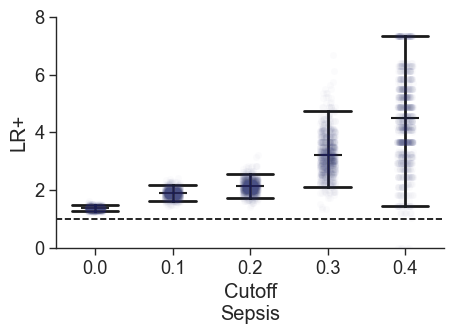

In [31]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    # width_ratios=[1, 1, 1],
    # constrained_layout=True,
    # gridspec_kw={"hspace": 0.15},
    #sharey="row",
)

sns.pointplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs
)

sns.stripplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#495084",
    linewidth=0,
    legend=False,
    alpha=0.02,
)

axs.set_xlabel("Cutoff\nSepsis")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.1f}" for val in mort_lr_df['Cutoff']],
)

axs.set_ylim((0, 8))

fig.set_size_inches(
    (5, 3)
)

fig.savefig("mortality_lr.pdf", bbox_inches="tight", dpi=300, transparent=True)



# Sepsis

In [32]:
combined_results = pd.read_csv(
    "sepsis_bootstrap_hero.csv",
)

outcome_col = "Sepsis Rates"
label_col = "sepsis_or_septic_shock"
title = "Sepsis"

In [33]:
od_median = combined_results[outcome_col].mean()
od_mad = combined_results[outcome_col].std()
od_mad, od_median

(0.20665413290387633, 0.6747331428571404)

In [34]:

cutoffs = [
    0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9
]

In [35]:
bootstrapped_recalls = []
bootstrapped_aucs = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:

    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    bootstrapped_aucs.append(
        roc_auc_score(
            subsample[label_col], subsample[col]
        )
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



od_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

od_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "AUC": bootstrapped_aucs,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `negative_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to control this behavior. To suppress this warning or turn it into an error, see Python's `warnings` module and `warnings.catch_warnings()`.
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `negative_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to control this behavior. To suppress this warning or turn it into an error, see Python's `warnings` module and `warnings.catch_warnings()`.
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_70636/1925523278.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


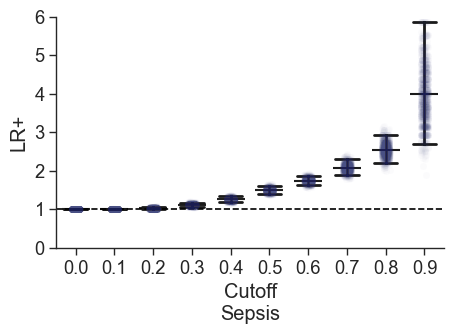

In [36]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    # width_ratios=[1, 1, 1],
    # constrained_layout=True,
    # gridspec_kw={"hspace": 0.15},
    #sharey="row",
)

sns.pointplot(
    data=od_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs
)

sns.stripplot(
    data=od_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#495084",
    linewidth=0,
    legend=False,
    alpha=0.02,
)

axs.set_xlabel("Cutoff\nSepsis")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.1f}" for val in od_lr_df['Cutoff']],
)

axs.set_ylim((0, 6))

fig.set_size_inches(
    (5, 3)
)

fig.savefig("sepsis_lr.pdf", bbox_inches="tight", dpi=300, transparent=True)



# Infection

In [37]:
combined_results = pd.read_csv(
    "infection_bootstrap_hero.csv",
)

outcome_col = "Infection Rates"
label_col = "verified_infection"
title = "Infection"

In [38]:
icu_median = combined_results[outcome_col].mean()
icu_mad = combined_results[outcome_col].std()
icu_mad, icu_median

(0.1920316388355709, 0.6447988571428567)

In [39]:
cutoffs = [
    max(icu_median - icu_mad, 0),
    icu_median,
    icu_median + icu_mad,
    icu_median + (icu_mad * 2),
    icu_median + (icu_mad * 3),
   icu_median + (icu_mad * 4),
]
cutoffs = [
    0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9
]

In [40]:
bootstrapped_recalls = []
bootstrapped_aucs = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:


    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    bootstrapped_aucs.append(
        roc_auc_score(
            subsample[label_col], subsample[col]
        )
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



icu_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

icu_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "AUC": bootstrapped_aucs,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `negative_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to control this behavior. To suppress this warning or turn it into an error, see Python's `warnings` module and `warnings.catch_warnings()`.
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `negative_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to control this behavior. To suppress this warning or turn it into an error, see Python's `warnings` module and `warnings.catch_warnings()`.
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_70636/2919865289.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


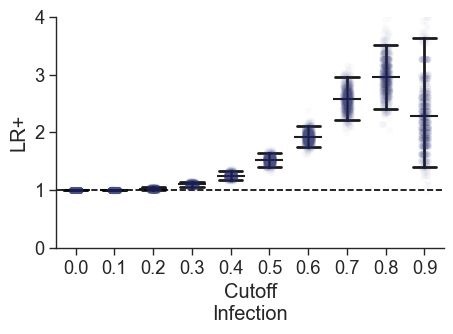

In [41]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    # width_ratios=[1, 1, 1],
    # constrained_layout=True,
    # gridspec_kw={"hspace": 0.15},
    #sharey="row",
)

sns.pointplot(
    data=icu_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs
)

sns.stripplot(
    data=icu_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#495084",
    linewidth=0,
    legend=False,
    alpha=0.02,
)

axs.set_xlabel("Cutoff\nInfection")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.1f}" for val in icu_lr_df['Cutoff']],
)

axs.set_ylim((0, 4))

fig.set_size_inches(
    (5, 3)
)

fig.savefig("infection_lr.pdf", bbox_inches="tight", dpi=300, transparent=True)



# Infection

In [42]:
combined_results = pd.read_csv(
    "combined_mortality_bootstrap_results_df.csv",
)

outcome_col = "30 Day Mortality"
label_col = "survival_30_day"
title = "30 Day Mortality"

In [43]:
mort_median = combined_results[outcome_col].mean()
mort_mad = combined_results[outcome_col].std()
mort_mad, mort_median

(0.12340856630225237, 0.12497035573122318)

In [44]:
cutoffs = [
    max(mort_median - mort_mad, 0),
    mort_median,
    mort_median + mort_mad,
    mort_median + (mort_mad * 2),
    #mort_median + (mort_mad * 3),
   # mort_median + (mort_mad * 4),
]
cutoffs = [
    0.0, 0.1, 0.2, 0.3, 0.4
]

In [45]:
bootstrapped_recalls = []
bootstrapped_aucs = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:

    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )


    bootstrapped_aucs.append(
        roc_auc_score(
            subsample[label_col], subsample[col]
        )
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



combined_mort_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

combined_mort_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "AUC": bootstrapped_aucs,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Doc

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_70636/1707147216.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


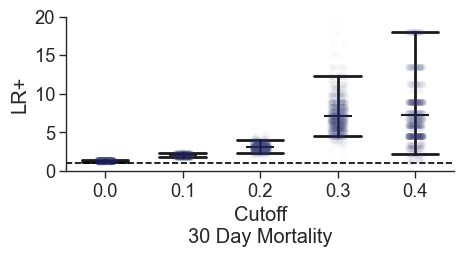

In [46]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    # width_ratios=[1, 1, 1],
    # constrained_layout=True,
    # gridspec_kw={"hspace": 0.15},
    #sharey="row",
)

sns.pointplot(
    data=combined_mort_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs
)

sns.stripplot(
    data=combined_mort_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#495084",
    linewidth=0,
    legend=False,
    alpha=0.02,
)

axs.set_xlabel("Cutoff\n30 Day Mortality")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.1f}" for val in mort_lr_df['Cutoff']],
)

axs.set_ylim((0, 20))

fig.set_size_inches(
    (5, 2)
)

fig.savefig("combined_mortality_lr.pdf", bbox_inches="tight", dpi=300, transparent=True)



In [47]:
combined_mort_lr_df[["LR+", "Cutoff"]].groupby("Cutoff").mean()

,LR+
Cutoff,
0.0,1.334731
0.1,2.046357
0.2,3.102654
0.3,7.116616
0.4,7.274235


In [48]:
mort_lr_df[["LR+", "Cutoff"]].groupby("Cutoff").mean()

,LR+
Cutoff,
0.0,1.369264
0.1,1.897020
0.2,2.130617
0.3,3.219949
0.4,4.490526
